# Supply Chain V3 — Disruption Impact Analysis

This notebook analyzes the time-series effects of operational disruptions generated by the Supply Chain V3 simulator.

## Analytical question

**What measurable effect do disruptions have on vehicle telemetry and shipment performance?**

The analysis correlates discrete events in `sc_events` with continuous telemetry in `sc_fleet_telemetry`.

Disruption types examined:

- Traffic congestion
- Heavy rain
- Mechanical breakdown
- Low-fuel refueling
- Reefer temperature excursion

The simulator remains the system of record for business behavior. This notebook is an analytical consumer of persisted simulation data.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

cwd = Path.cwd()
repo_root = cwd if (cwd / "pyproject.toml").exists() else cwd.parent

load_dotenv(repo_root / ".env")

database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise RuntimeError(
        "DATABASE_URL is not set. Copy .env.example to .env first."
    )

engine = create_engine(database_url)

print("SQLAlchemy engine configured for TimescaleDB")

SQLAlchemy engine configured for TimescaleDB


In [2]:
event_summary_sql = """
SELECT
    cause_code,
    event_type,
    COUNT(*) AS event_count,
    COUNT(DISTINCT shipment_id) AS affected_shipments
FROM sc_events
WHERE cause_code IS NOT NULL
GROUP BY
    cause_code,
    event_type
ORDER BY
    cause_code,
    event_type;
"""

event_summary = pd.read_sql_query(event_summary_sql, engine)

event_summary

,cause_code,event_type,event_count,affected_shipments
0,HEAVY_RAIN,DISRUPTION_ENDED,3,3
1,HEAVY_RAIN,DISRUPTION_STARTED,3,3
2,HEAVY_RAIN,ETA_UPDATED,3,3
3,LOW_FUEL_REFUEL,ETA_UPDATED,2,2
4,LOW_FUEL_REFUEL,FUEL_STOP_ENDED,2,2
5,LOW_FUEL_REFUEL,FUEL_STOP_STARTED,2,2
6,MECHANICAL_BREAKDOWN,DISRUPTION_ENDED,5,5
7,MECHANICAL_BREAKDOWN,DISRUPTION_STARTED,5,5
8,MECHANICAL_BREAKDOWN,ETA_UPDATED,5,5
9,REEFER_TEMP_EXCURSION,CARGO_EXCEPTION_ENDED,3,3


## 2. Construct disruption episodes

`sc_events` stores discrete lifecycle events such as disruption start and end.

For time-series analysis, these events are transformed into **episodes** with:

- shipment
- vehicle
- cause
- start time
- end time
- duration

This converts event data into time intervals that can be correlated with continuous vehicle telemetry.

In [3]:
episode_sql = """
WITH starts AS (
    SELECT
        run_id,
        shipment_id,
        vehicle_id,
        cause_code,
        time AS start_time
    FROM sc_events
    WHERE event_type IN (
        'DISRUPTION_STARTED',
        'FUEL_STOP_STARTED',
        'CARGO_EXCEPTION_STARTED'
    )
),
ends AS (
    SELECT
        run_id,
        shipment_id,
        vehicle_id,
        cause_code,
        time AS end_time
    FROM sc_events
    WHERE event_type IN (
        'DISRUPTION_ENDED',
        'FUEL_STOP_ENDED',
        'CARGO_EXCEPTION_ENDED'
    )
)
SELECT
    s.run_id,
    s.shipment_id,
    s.vehicle_id,
    s.cause_code,
    s.start_time,
    e.end_time,
    EXTRACT(EPOCH FROM (e.end_time - s.start_time)) / 60.0
        AS duration_minutes
FROM starts AS s
JOIN ends AS e
    ON e.run_id = s.run_id
   AND e.shipment_id = s.shipment_id
   AND e.vehicle_id = s.vehicle_id
   AND e.cause_code = s.cause_code
   AND e.end_time >= s.start_time
ORDER BY s.start_time;
"""

episodes = pd.read_sql_query(episode_sql, engine)

episodes

,run_id,shipment_id,vehicle_id,cause_code,start_time,end_time,duration_minutes
0,1,4,4,TRAFFIC_CONGESTION,2026-08-23 00:53:46+00:00,2026-08-23 01:53:46+00:00,60.0
1,1,5,5,TRAFFIC_CONGESTION,2026-08-23 02:53:46+00:00,2026-08-23 03:53:46+00:00,60.0
2,1,6,6,TRAFFIC_CONGESTION,2026-08-23 04:53:46+00:00,2026-08-23 05:53:46+00:00,60.0
3,1,7,7,TRAFFIC_CONGESTION,2026-08-23 06:53:46+00:00,2026-08-23 07:53:46+00:00,60.0
4,1,8,8,TRAFFIC_CONGESTION,2026-08-23 08:53:46+00:00,2026-08-23 09:53:46+00:00,60.0
5,1,9,5,TRAFFIC_CONGESTION,2026-08-23 11:05:18.307692+00:00,2026-08-23 12:05:18.307692+00:00,60.0
6,1,10,8,HEAVY_RAIN,2026-08-23 16:53:46+00:00,2026-08-23 17:53:46+00:00,60.0
7,1,11,5,HEAVY_RAIN,2026-08-23 17:59:01.563506+00:00,2026-08-23 18:59:01.563506+00:00,60.0
8,1,12,6,HEAVY_RAIN,2026-08-23 21:58:39.877551+00:00,2026-08-23 22:58:39.877551+00:00,60.0
9,1,13,1,MECHANICAL_BREAKDOWN,2026-08-23 22:13:12.535151+00:00,2026-08-23 23:13:12.535151+00:00,60.0


In [4]:
episode_summary = (
    episodes
    .groupby("cause_code")
    .agg(
        episodes=("shipment_id", "count"),
        avg_duration_min=("duration_minutes", "mean"),
        min_duration_min=("duration_minutes", "min"),
        max_duration_min=("duration_minutes", "max"),
    )
    .reset_index()
)

episode_summary

,cause_code,episodes,avg_duration_min,min_duration_min,max_duration_min
0,HEAVY_RAIN,3,60.0,60.0,60.0
1,LOW_FUEL_REFUEL,2,20.0,20.0,20.0
2,MECHANICAL_BREAKDOWN,5,60.0,60.0,60.0
3,REEFER_TEMP_EXCURSION,3,60.0,60.0,60.0
4,TRAFFIC_CONGESTION,6,60.0,60.0,60.0


## 3. Measure telemetry before, during, and after disruptions

A disruption event by itself tells us **what happened**.

Telemetry tells us **what effect it had**.

For every disruption episode, vehicle telemetry is divided into three analytical windows:

- **BEFORE** — 30 minutes immediately preceding the disruption
- **DURING** — the disruption interval
- **AFTER** — 30 minutes immediately following the disruption

This allows us to measure whether vehicle behavior changed when the disruption occurred and whether it recovered afterward.

In [5]:
impact_sql = """
WITH starts AS (
    SELECT
        run_id,
        shipment_id,
        vehicle_id,
        cause_code,
        time AS start_time
    FROM sc_events
    WHERE event_type IN (
        'DISRUPTION_STARTED',
        'FUEL_STOP_STARTED',
        'CARGO_EXCEPTION_STARTED'
    )
),
ends AS (
    SELECT
        run_id,
        shipment_id,
        vehicle_id,
        cause_code,
        time AS end_time
    FROM sc_events
    WHERE event_type IN (
        'DISRUPTION_ENDED',
        'FUEL_STOP_ENDED',
        'CARGO_EXCEPTION_ENDED'
    )
),
episodes AS (
    SELECT
        s.run_id,
        s.shipment_id,
        s.vehicle_id,
        s.cause_code,
        s.start_time,
        e.end_time
    FROM starts AS s
    JOIN ends AS e
        ON e.run_id = s.run_id
       AND e.shipment_id = s.shipment_id
       AND e.vehicle_id = s.vehicle_id
       AND e.cause_code = s.cause_code
       AND e.end_time >= s.start_time
),
labeled_telemetry AS (
    SELECT
        e.run_id,
        e.shipment_id,
        e.vehicle_id,
        e.cause_code,
        e.start_time,
        e.end_time,
        t.time,
        t.speed_kmh,
        t.fuel_level_pct,
        t.cargo_temp_c,
        CASE
            WHEN t.time < e.start_time THEN 'BEFORE'
            WHEN t.time < e.end_time THEN 'DURING'
            ELSE 'AFTER'
        END AS phase
    FROM episodes AS e
    JOIN sc_fleet_telemetry AS t
        ON t.run_id = e.run_id
       AND t.shipment_id = e.shipment_id
       AND t.vehicle_id = e.vehicle_id
       AND t.time >= e.start_time - INTERVAL '30 minutes'
       AND t.time < e.end_time + INTERVAL '30 minutes'
)
SELECT
    run_id,
    shipment_id,
    vehicle_id,
    cause_code,
    start_time,
    end_time,
    phase,
    COUNT(*) AS telemetry_samples,
    AVG(speed_kmh) AS avg_speed_kmh,
    MIN(speed_kmh) AS min_speed_kmh,
    MAX(speed_kmh) AS max_speed_kmh,
    AVG(fuel_level_pct) AS avg_fuel_pct,
    AVG(cargo_temp_c) AS avg_cargo_temp_c
FROM labeled_telemetry
GROUP BY
    run_id,
    shipment_id,
    vehicle_id,
    cause_code,
    start_time,
    end_time,
    phase
ORDER BY
    start_time,
    CASE phase
        WHEN 'BEFORE' THEN 1
        WHEN 'DURING' THEN 2
        WHEN 'AFTER' THEN 3
        ELSE 4
    END;
"""

impact = pd.read_sql_query(impact_sql, engine)

impact

,run_id,shipment_id,vehicle_id,cause_code,start_time,end_time,phase,telemetry_samples,avg_speed_kmh,min_speed_kmh,max_speed_kmh,avg_fuel_pct,avg_cargo_temp_c
0,1,4,4,TRAFFIC_CONGESTION,2026-08-23 00:53:46+00:00,2026-08-23 01:53:46+00:00,BEFORE,2,81.600000,81.60,81.60,94.785000,NaN
1,1,4,4,TRAFFIC_CONGESTION,2026-08-23 00:53:46+00:00,2026-08-23 01:53:46+00:00,DURING,6,47.600000,40.80,81.60,94.385000,NaN
2,1,4,4,TRAFFIC_CONGESTION,2026-08-23 00:53:46+00:00,2026-08-23 01:53:46+00:00,AFTER,3,68.000000,40.80,81.60,93.986667,NaN
3,1,5,5,TRAFFIC_CONGESTION,2026-08-23 02:53:46+00:00,2026-08-23 03:53:46+00:00,BEFORE,2,78.000000,78.00,78.00,94.810000,NaN
4,1,5,5,TRAFFIC_CONGESTION,2026-08-23 02:53:46+00:00,2026-08-23 03:53:46+00:00,DURING,6,45.500000,39.00,78.00,94.458333,NaN
5,1,5,5,TRAFFIC_CONGESTION,2026-08-23 02:53:46+00:00,2026-08-23 03:53:46+00:00,AFTER,3,65.000000,39.00,78.00,94.110000,NaN
6,1,6,6,TRAFFIC_CONGESTION,2026-08-23 04:53:46+00:00,2026-08-23 05:53:46+00:00,BEFORE,2,78.400000,78.40,78.40,94.800000,NaN
7,1,6,6,TRAFFIC_CONGESTION,2026-08-23 04:53:46+00:00,2026-08-23 05:53:46+00:00,DURING,6,45.733333,39.20,78.40,94.433333,NaN
8,1,6,6,TRAFFIC_CONGESTION,2026-08-23 04:53:46+00:00,2026-08-23 05:53:46+00:00,AFTER,3,65.333333,39.20,78.40,94.066667,NaN
9,1,7,7,TRAFFIC_CONGESTION,2026-08-23 06:53:46+00:00,2026-08-23 07:53:46+00:00,BEFORE,2,86.700000,86.70,86.70,94.795000,NaN


In [6]:
phase_summary = (
    impact
    .groupby(["cause_code", "phase"])
    .agg(
        episodes=("shipment_id", "nunique"),
        samples=("telemetry_samples", "sum"),
        avg_speed_kmh=("avg_speed_kmh", "mean"),
        min_speed_kmh=("min_speed_kmh", "min"),
        avg_fuel_pct=("avg_fuel_pct", "mean"),
        avg_cargo_temp_c=("avg_cargo_temp_c", "mean"),
    )
    .reset_index()
)

phase_order = ["BEFORE", "DURING", "AFTER"]

phase_summary["phase"] = pd.Categorical(
    phase_summary["phase"],
    categories=phase_order,
    ordered=True,
)

phase_summary = phase_summary.sort_values(
    ["cause_code", "phase"]
)

phase_summary

,cause_code,phase,episodes,samples,avg_speed_kmh,min_speed_kmh,avg_fuel_pct,avg_cargo_temp_c
1,HEAVY_RAIN,BEFORE,3,6,82.766667,81.00,94.790000,NaN
2,HEAVY_RAIN,DURING,3,18,62.075000,56.70,94.331111,NaN
0,HEAVY_RAIN,AFTER,3,9,74.490000,56.70,93.844444,NaN
4,LOW_FUEL_REFUEL,BEFORE,2,2,85.000000,84.00,25.640000,NaN
5,LOW_FUEL_REFUEL,DURING,2,2,0.000000,0.00,90.000000,NaN
3,LOW_FUEL_REFUEL,AFTER,2,4,85.000000,84.00,89.457500,NaN
7,MECHANICAL_BREAKDOWN,BEFORE,5,10,82.420000,79.56,94.796000,NaN
8,MECHANICAL_BREAKDOWN,DURING,5,30,0.000000,0.00,94.594000,NaN
6,MECHANICAL_BREAKDOWN,AFTER,5,10,82.420000,79.56,94.390000,NaN
10,REEFER_TEMP_EXCURSION,BEFORE,3,6,80.600000,78.40,94.795000,4.0


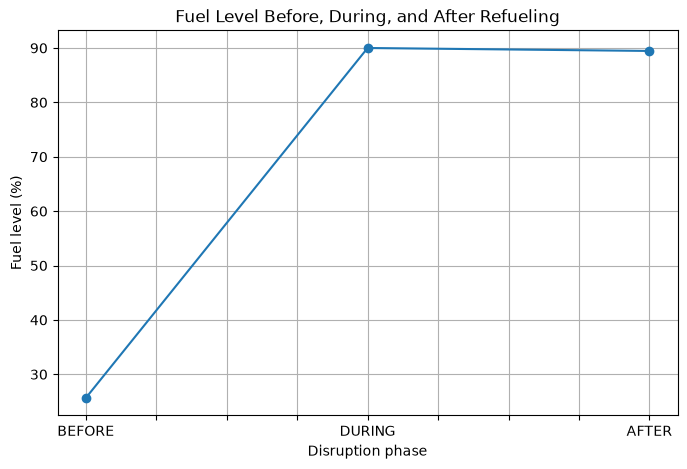

In [7]:
fuel_summary = phase_summary[
    phase_summary["cause_code"] == "LOW_FUEL_REFUEL"
].copy()

fuel_summary = fuel_summary.set_index("phase").reindex(
    ["BEFORE", "DURING", "AFTER"]
)

fuel_summary["avg_fuel_pct"].plot(
    marker="o",
    figsize=(8, 5),
    title="Fuel Level Before, During, and After Refueling",
)

plt.xlabel("Disruption phase")
plt.ylabel("Fuel level (%)")
plt.grid(True)
plt.show()

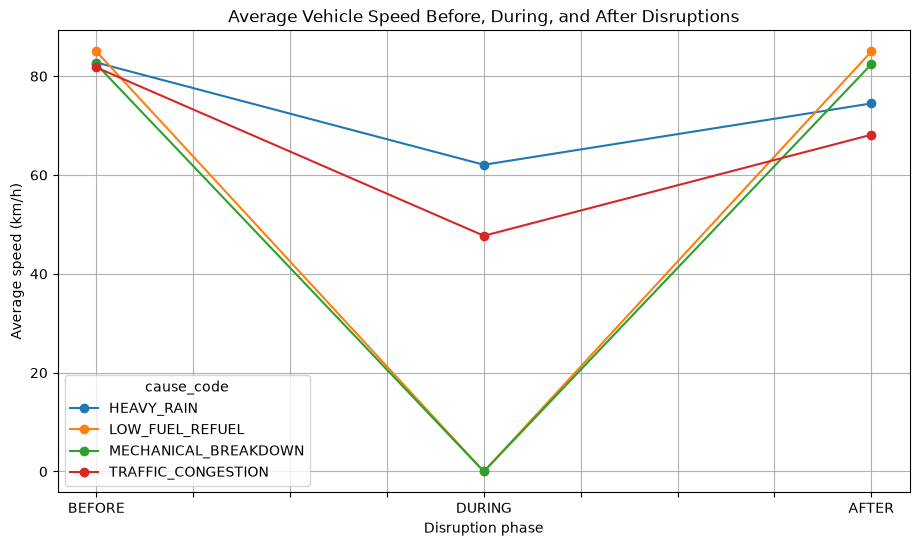

In [8]:
speed_summary = phase_summary[
    phase_summary["cause_code"].isin(
        [
            "TRAFFIC_CONGESTION",
            "HEAVY_RAIN",
            "MECHANICAL_BREAKDOWN",
            "LOW_FUEL_REFUEL",
        ]
    )
].copy()

pivot_speed = speed_summary.pivot(
    index="phase",
    columns="cause_code",
    values="avg_speed_kmh",
)

pivot_speed = pivot_speed.reindex(["BEFORE", "DURING", "AFTER"])

pivot_speed.plot(
    marker="o",
    figsize=(11, 6),
    title="Average Vehicle Speed Before, During, and After Disruptions",
)

plt.xlabel("Disruption phase")
plt.ylabel("Average speed (km/h)")
plt.grid(True)
plt.show()

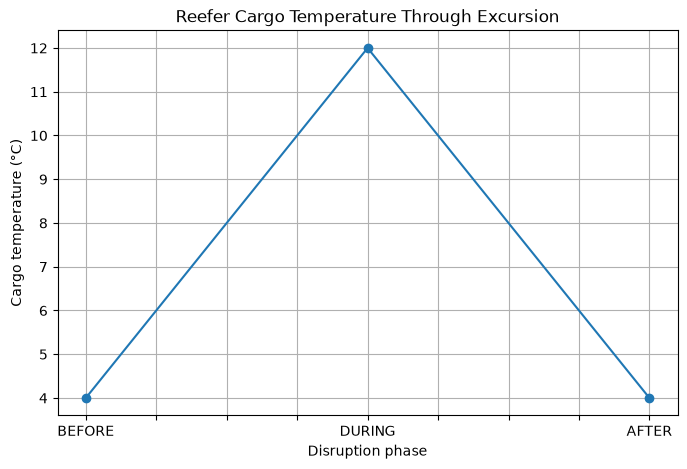

In [9]:
reefer_summary = phase_summary[
    phase_summary["cause_code"] == "REEFER_TEMP_EXCURSION"
].copy()

reefer_summary = reefer_summary.set_index("phase").reindex(
    ["BEFORE", "DURING", "AFTER"]
)

reefer_summary["avg_cargo_temp_c"].plot(
    marker="o",
    figsize=(8, 5),
    title="Reefer Cargo Temperature Through Excursion",
)

plt.xlabel("Disruption phase")
plt.ylabel("Cargo temperature (°C)")
plt.grid(True)
plt.show()

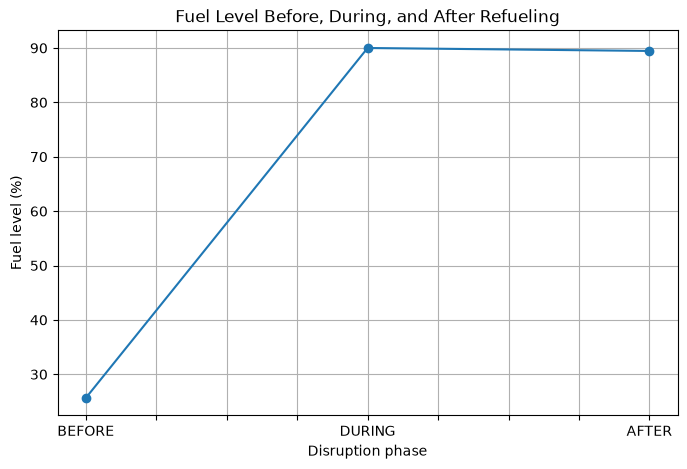

In [10]:
fuel_summary = phase_summary[
    phase_summary["cause_code"] == "LOW_FUEL_REFUEL"
].copy()

fuel_summary = fuel_summary.set_index("phase").reindex(
    ["BEFORE", "DURING", "AFTER"]
)

fuel_summary["avg_fuel_pct"].plot(
    marker="o",
    figsize=(8, 5),
    title="Fuel Level Before, During, and After Refueling",
)

plt.xlabel("Disruption phase")
plt.ylabel("Fuel level (%)")
plt.grid(True)
plt.show()

## 4. Quantify disruption impact

The previous analysis shows clear before/during/after patterns.

This section measures the magnitude of those changes.

For speed-related disruptions, impact is calculated as:

**Speed reduction (%) = (Before speed − During speed) / Before speed × 100**

For reefer excursions, the temperature increase is measured in degrees Celsius.

For refueling events, the fuel increase is measured in percentage points.

In [11]:
def phase_value(df, cause, phase, column):
    row = df[
        (df["cause_code"] == cause)
        & (df["phase"] == phase)
    ]

    if row.empty:
        return float("nan")

    return float(row.iloc[0][column])


speed_causes = [
    "TRAFFIC_CONGESTION",
    "HEAVY_RAIN",
    "MECHANICAL_BREAKDOWN",
    "LOW_FUEL_REFUEL",
]

impact_rows = []

for cause in speed_causes:
    before_speed = phase_value(
        phase_summary, cause, "BEFORE", "avg_speed_kmh"
    )

    during_speed = phase_value(
        phase_summary, cause, "DURING", "avg_speed_kmh"
    )

    reduction_pct = (
        (before_speed - during_speed)
        / before_speed
        * 100
    )

    impact_rows.append(
        {
            "cause_code": cause,
            "before_speed_kmh": before_speed,
            "during_speed_kmh": during_speed,
            "speed_reduction_pct": reduction_pct,
        }
    )

speed_impact = pd.DataFrame(impact_rows)

speed_impact

,cause_code,before_speed_kmh,during_speed_kmh,speed_reduction_pct
0,TRAFFIC_CONGESTION,81.783333,47.706944,41.666667
1,HEAVY_RAIN,82.766667,62.075000,25.000000
2,MECHANICAL_BREAKDOWN,82.420000,0.000000,100.000000
3,LOW_FUEL_REFUEL,85.000000,0.000000,100.000000


In [12]:
reefer_before = phase_value(
    phase_summary,
    "REEFER_TEMP_EXCURSION",
    "BEFORE",
    "avg_cargo_temp_c",
)

reefer_during = phase_value(
    phase_summary,
    "REEFER_TEMP_EXCURSION",
    "DURING",
    "avg_cargo_temp_c",
)

fuel_before = phase_value(
    phase_summary,
    "LOW_FUEL_REFUEL",
    "BEFORE",
    "avg_fuel_pct",
)

fuel_during = phase_value(
    phase_summary,
    "LOW_FUEL_REFUEL",
    "DURING",
    "avg_fuel_pct",
)

operational_impact = pd.DataFrame(
    [
        {
            "metric": "Reefer temperature increase",
            "before": reefer_before,
            "during": reefer_during,
            "change": reefer_during - reefer_before,
            "unit": "°C",
        },
        {
            "metric": "Fuel level increase",
            "before": fuel_before,
            "during": fuel_during,
            "change": fuel_during - fuel_before,
            "unit": "percentage points",
        },
    ]
)

operational_impact

,metric,before,during,change,unit
0,Reefer temperature increase,4.00,12.0,8.00,°C
1,Fuel level increase,25.64,90.0,64.36,percentage points


In [13]:
def disruption_metric(cause, column):
    return float(
        speed_impact.loc[
            speed_impact["cause_code"] == cause,
            column,
        ].iloc[0]
    )


traffic_reduction = disruption_metric(
    "TRAFFIC_CONGESTION", "speed_reduction_pct"
)

rain_reduction = disruption_metric(
    "HEAVY_RAIN", "speed_reduction_pct"
)

mechanical_reduction = disruption_metric(
    "MECHANICAL_BREAKDOWN", "speed_reduction_pct"
)

fuel_reduction = disruption_metric(
    "LOW_FUEL_REFUEL", "speed_reduction_pct"
)


results = pd.DataFrame(
    [
        {
            "disruption": "Traffic congestion",
            "measured_effect": f"{traffic_reduction:.2f}% speed reduction",
        },
        {
            "disruption": "Heavy rain",
            "measured_effect": f"{rain_reduction:.2f}% speed reduction",
        },
        {
            "disruption": "Mechanical breakdown",
            "measured_effect": f"{mechanical_reduction:.2f}% speed reduction",
        },
        {
            "disruption": "Low-fuel refuel",
            "measured_effect": (
                f"{fuel_reduction:.2f}% speed reduction; "
                f"+{fuel_during - fuel_before:.2f} fuel percentage points"
            ),
        },
        {
            "disruption": "Reefer temperature excursion",
            "measured_effect": (
                f"+{reefer_during - reefer_before:.2f}°C cargo temperature"
            ),
        },
    ]
)

results

,disruption,measured_effect
0,Traffic congestion,41.67% speed reduction
1,Heavy rain,25.00% speed reduction
2,Mechanical breakdown,100.00% speed reduction
3,Low-fuel refuel,100.00% speed reduction; +64.36 fuel percentag...
4,Reefer temperature excursion,+8.00°C cargo temperature


## 5. Analytical conclusions

The disruption analysis demonstrates that Supply Chain V3 produces distinct and measurable causal signatures in its time-series telemetry.

### Traffic congestion

Average vehicle speed decreased from **81.78 km/h to 47.71 km/h**, a **41.67% reduction** during congestion.

The effect is substantial but does not stop vehicle movement, distinguishing congestion from a mechanical failure or operational stop.

### Heavy rain

Average speed decreased from **82.77 km/h to 62.08 km/h**, a **25.00% reduction**.

The smaller speed reduction compared with traffic congestion demonstrates that different disruption types produce different operational effects.

### Mechanical breakdown

Average vehicle speed decreased from **82.42 km/h to 0 km/h**, representing a **100% reduction in movement**.

After the disruption, vehicle speed returned to its pre-disruption average, demonstrating a clear failure-and-recovery signature.

### Low-fuel refueling

Vehicle speed decreased from **85.00 km/h to 0 km/h** during the fuel stop.

At the same time, average fuel level increased from **25.64% to 90.00%**, an increase of **64.36 percentage points**.

This creates a multivariate operational signature: vehicle movement stops while fuel state changes sharply.

### Reefer temperature excursion

Cargo temperature increased from **4°C to 12°C**, an **8°C excursion**, before recovering to 4°C.

Average vehicle speed remained approximately **80.6 km/h** throughout the event.

This demonstrates that a cargo-condition exception can occur independently of vehicle movement.

## Overall finding

The simulator produces disruption-specific time-series behavior rather than a single generic failure pattern.

Discrete events in `sc_events` can be correlated with continuous measurements in `sc_fleet_telemetry` to reconstruct operational episodes and measure their effects before, during, and after an event.

This provides a foundation for more advanced analysis including anomaly detection, event correlation, service-level impact analysis, root-cause analysis, and predictive modeling.